In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler  # Standard scaler is used to do mean 0 and std 1 cause machine learning can't  do partiality

1. Reading the CSV File

In [4]:
df=pd.read_csv('ecommerce_customers_LPA.csv')
df.head()

,CustomerID,Age,Annual_Income_LPA,Spending_Score
0,96,31,12,72
1,16,20,4,66
2,31,26,2,84
3,159,60,3,32
4,129,36,35,33


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         200 non-null    int64
 1   Age                200 non-null    int64
 2   Annual_Income_LPA  200 non-null    int64
 3   Spending_Score     200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [6]:
df.shape

(200, 4)

In [7]:
df.describe()

,CustomerID,Age,Annual_Income_LPA,Spending_Score
count,200.000000,200.00000,200.00000,200.000000
mean,100.500000,36.75500,17.22500,60.605000
std,57.879185,12.50427,12.94264,21.644199
min,1.000000,18.00000,2.00000,6.000000
25%,50.750000,27.00000,6.00000,46.000000
50%,100.500000,34.00000,14.00000,66.000000
75%,150.250000,45.00000,25.25000,76.000000
max,200.000000,70.00000,56.00000,100.000000


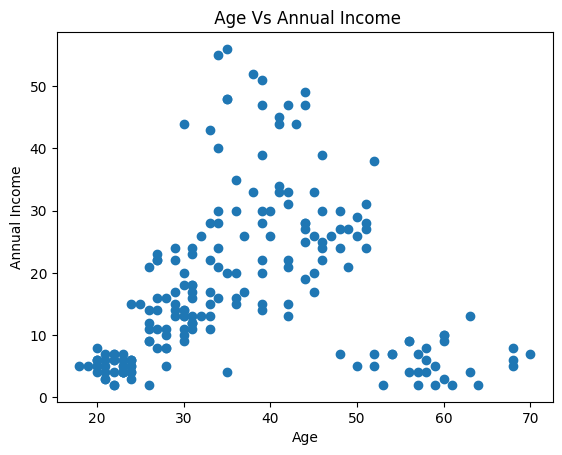

In [10]:
# Age vs annaul_income
plt.Figure(figsize=(5,8))
plt.scatter(df['Age'],df['Annual_Income_LPA'])
plt.xlabel("Age")
plt.ylabel("Annual Income")
plt.title(' Age Vs Annual Income')
plt.show()


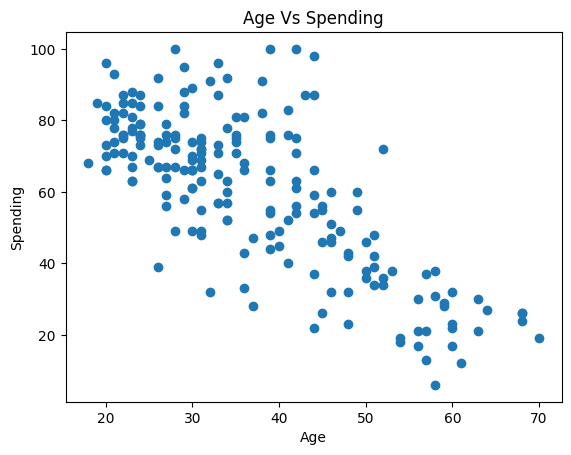

In [11]:
# Age vs Spending
plt.Figure(figsize=(5,8))
plt.scatter(df['Age'],df['Spending_Score'])
plt.xlabel('Age')
plt.ylabel("Spending")
plt.title("Age Vs Spending")
plt.show()

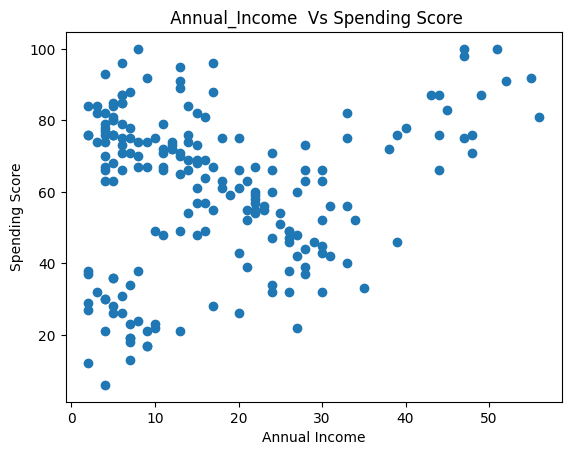

In [13]:
#Annual Income Vs Spending score
plt.Figure(figsize=(5,8))
plt.scatter(df['Annual_Income_LPA'],df['Spending_Score'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title(" Annual_Income  Vs Spending Score")
plt.show()

In [19]:
## Feature Scaling
features=['Age','Annual_Income_LPA','Spending_Score']
X=df[features].values

scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)
## Converting mean and median value 0 and 1

print('X_mean value',x_scaled.mean(axis=0).round(3))
print('X_std value',x_scaled.std(axis=0).round(3))

X_mean value [-0. -0.  0.]
X_std value [1. 1. 1.]


In [20]:
from sklearn.cluster import KMeans

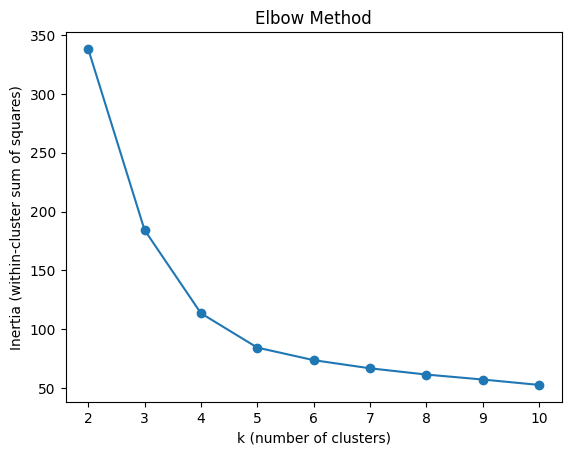

In [22]:
#Elbow method

inertias = []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(K), inertias, marker="o")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method")
plt.show()


Silhouette scores: {2: 0.422, 3: 0.474, 4: 0.507, 5: 0.446, 6: 0.409, 7: 0.394, 8: 0.393, 9: 0.378, 10: 0.344}
Best k by silhouette: 4


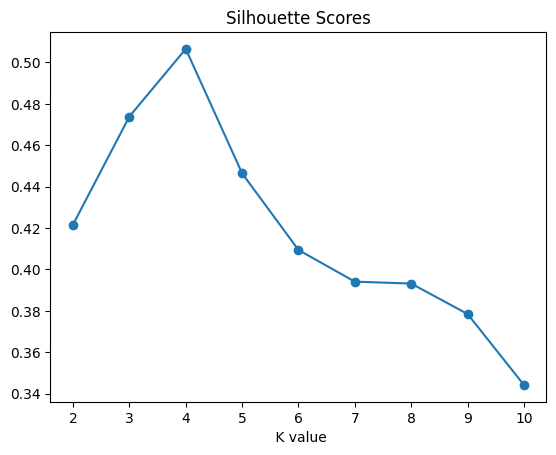

In [27]:
## Now we have to do calculate value of k using silhouette_score:- which has more silhoutte value we will consider the value of k
sil_scores=[]
for k in K:
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=km.fit_predict(x_scaled)
    score=silhouette_score(x_scaled,labels)
    sil_scores.append(score)

best_k = int(K[np.argmax(sil_scores)])
print("Silhouette scores:", dict(zip(K, [round(s, 3) for s in sil_scores])))
print("Best k by silhouette:", best_k)

plt.Figure()
plt.plot(list(K),sil_scores,marker='o')
plt.xlabel(" K value")
plt.title('Silhouette Scores')
plt.show()

In [ ]:
## Now we have to fit the model
k_final=best_k
km=KMeans(n_clusters=k_final,random_state=42,n_init=10)
labels=km.fit_predict(x_scaled)

## Assigning a new column as cluster
df['cluster']=labels

In [29]:
df.head()

,CustomerID,Age,Annual_Income_LPA,Spending_Score,cluster
0,96,31,12,72,1
1,16,20,4,66,1
2,31,26,2,84,1
3,159,60,3,32,2
4,129,36,35,33,0


In [30]:
df.cluster.value_counts()

cluster
1    84
0    66
2    30
3    20
Name: count, dtype: int64

In [32]:
profile=df.groupby('cluster')[['Age','Annual_Income_LPA','Spending_Score']].mean().round(2)
profile

,Age,Annual_Income_LPA,Spending_Score
cluster,,,
0,39.88,24.15,50.56
1,25.98,9.15,75.92
2,58.63,5.97,25.13
3,38.90,45.15,82.65


In [34]:
cluster_names = {
    0: "Balanced Customers",
    1: "Young Spenders",
    2: "Seniors • Low Spending",
    3: "High Income • High Spending"
}

df["Segment"] = df["cluster"].map(cluster_names)
df.head()


,CustomerID,Age,Annual_Income_LPA,Spending_Score,cluster,Segment
0,96,31,12,72,1,Young Spenders
1,16,20,4,66,1,Young Spenders
2,31,26,2,84,1,Young Spenders
3,159,60,3,32,2,Seniors • Low Spending
4,129,36,35,33,0,Balanced Customers


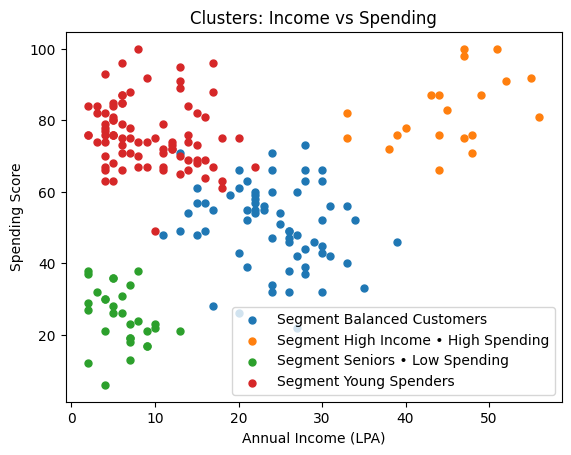

In [35]:
plt.figure()
for c in sorted(df["Segment"].unique()):
    mask = df["Segment"] == c
    plt.scatter(df.loc[mask, "Annual_Income_LPA"], df.loc[mask, "Spending_Score"], label=f"Segment {c}", s=25)
plt.xlabel("Annual Income (LPA)")
plt.ylabel("Spending Score")
plt.title("Clusters: Income vs Spending")
plt.legend()
plt.show()


In [36]:
import joblib

In [37]:
joblib.dump(km, 'kmeans_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(best_k, 'best_k.joblib')

['best_k.joblib']